# 2. Nuisance-Model Diagnostics

This notebook trains and evaluates the nuisance models used by the off-policy evaluation layer, then regenerates **Paper Figure 4**, a three-panel nuisance-model calibration diagnostic.

The notebook is intentionally placed after the EDA notebook. Figures 2 and 3 establish that the auction data are worth analyzing; Figure 4 checks whether the learned components used later by direct-method and doubly robust estimators have enough predictive signal to be useful rather than decorative.


## What This Notebook Creates

Inputs from setup:

- `artifacts/workspace/data/processed/season2_development_or_full_panel_current_scope.parquet`
- `artifacts/workspace/metadata/season2_panel_manifest.csv`

Generated analysis artifacts:

- `metadata/feature_label_contract.csv`
- `metadata/prototype_model_metrics.csv`
- `metadata/prototype_calibration_summary.csv`
- `metadata/prototype_regression_calibration_summary.csv`
- `metadata/nuisance_model_registry.csv`
- corresponding table copies under `tables/`

Generated paper figure:

- `artifacts/figures/04_nuisance_model_calibration.png`

The figure is a 1x3 panel: probability calibration, pay-price regression calibration, and value-proxy regression calibration.


## Why Nuisance Models Enter the DSS

The deterministic replay layer can mechanically answer questions like: if the logged floor had been higher, would the logged bid still have cleared, and what payment would have been retained? However, the paper also uses model-assisted evidence. Direct-method and doubly robust diagnostics require learned outcome components, and guardrail interpretation benefits from knowing whether fill, click, conversion, and value proxies are predictable from pre-auction features.

The key design rule is leakage control. The models use features available before or at auction time, such as bid price, floor, inventory dimensions, exchange, geography, advertiser, hour, and user-tag counts. They do not use post-auction labels as features. The target labels are `filled`, `pay_price`, `clicked`, `converted`, and `value_proxy_lambda_10`.

In [12]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")

Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [13]:
import importlib

import checks
import config as project_config
import data_access
import figures
import nuisance_models
import progress as progress_module
from IPython.display import Image, display
import pandas as pd

# Jupyter kernels keep imported modules in memory. Reload the local source modules so
# this notebook picks up recent code edits without requiring a manual kernel restart.
for module in [checks, project_config, data_access, figures, nuisance_models, progress_module]:
    importlib.reload(module)

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths, RawPipelineConfig
from data_access import Workspace
from figures import FigureRenderer
from nuisance_models import NuisanceModelTrainer
from progress import ProgressLogger


In [14]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)

season2_panel_path = paths.processed_data_dir / "season2_development_or_full_panel_current_scope.parquet"
if not season2_panel_path.exists():
    raise FileNotFoundError(f"Run notebooks/0_setup.ipynb first. Missing: {season2_panel_path}")

print(f"Season 2 panel: {season2_panel_path.relative_to(REPO_ROOT)}")

Season 2 panel: artifacts/workspace/data/processed/season2_development_or_full_panel_current_scope.parquet


## Modeling Sample and Time Split

This notebook reads the combined Season 2 setup panel but only loads columns needed by the nuisance-model trainer. The trainer then draws a reproducible modeling sample if the panel is larger than `nuisance_sample_rows`.

The chronological `time_split` is used here. Models are fit on the `train` slice and evaluated on the `test` slice. This split is not used to restrict deterministic auction replay; it is used to avoid judging model quality only on the same rows used for fitting.

In [15]:
config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=True,
    clean_workspace=False,
)
trainer = NuisanceModelTrainer(workspace, config, progress=progress)

target_columns = ["filled", "pay_price", "clicked", "converted", "value_proxy_lambda_10"]
support_columns = ["bid_id", "event_time", "time_split"]
model_columns = list(dict.fromkeys([*trainer.feature_columns, *target_columns, *support_columns]))

panel_for_models = pd.read_parquet(season2_panel_path, columns=model_columns)

print(f"Loaded {len(panel_for_models):,} Season 2 rows for nuisance-model sampling.")
print(f"Loaded {len(panel_for_models.columns):,} columns: {', '.join(panel_for_models.columns)}")

Loaded 53,289,330 Season 2 rows for nuisance-model sampling.
Loaded 25 columns: bid_price, slot_floor_price, bid_floor_gap, floor_to_bid_ratio, slot_width, slot_height, slot_area, hour, day_of_week, user_tag_count, has_user_tags, region, city, ad_exchange, advertiser_id, slot_visibility, slot_format, filled, pay_price, clicked, converted, value_proxy_lambda_10, bid_id, event_time, time_split


In [16]:
split_summary = (
    panel_for_models.groupby("time_split", as_index=False, observed=True)
    .agg(
        rows=("filled", "size"),
        fill_rate=("filled", "mean"),
        click_rate=("clicked", "mean"),
        conversion_rate=("converted", "mean"),
        mean_pay_price=("pay_price", "mean"),
    )
    .sort_values("time_split")
)
split_summary

,time_split,rows,fill_rate,click_rate,conversion_rate,mean_pay_price
0,test,10657866,0.345617,0.000281,0.000018,79.523302
1,train,31973598,0.170956,0.000109,0.000004,76.335898
2,validation,10657866,0.285304,0.000212,0.000007,80.119084


The split summary is a pre-model sanity check. If a split has no filled impressions, no clicks, or no conversions, then some nuisance models may be skipped or should be interpreted cautiously. Conversions are especially sparse in display-ad auction logs, so the conversion model is treated as a diagnostic/prototype component rather than a strong standalone claim.

## Train and Evaluate the Nuisance Models

The trainer estimates five prototype models:

1. fill probability model for `filled`,
2. pay-price regression model for `pay_price` among filled impressions,
3. click-through model for `clicked` among filled impressions,
4. conversion model for `converted` among filled impressions,
5. value-proxy regression model for `value_proxy_lambda_10` among filled impressions.

The paper does not claim that these models solve bidding or user-response prediction. Their role is narrower: they provide an auditable nuisance layer for model-assisted policy diagnostics. Model status, metrics, calibration, and risks are written as artifacts instead of being hidden inside the figure.

In [17]:
trainer.run(panel_for_models)

required_nuisance_artifacts = [
    paths.metadata_dir / "prototype_model_metrics.csv",
    paths.metadata_dir / "prototype_calibration_summary.csv",
    paths.metadata_dir / "prototype_regression_calibration_summary.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required_nuisance_artifacts if not path.exists()]
if missing:
    raise RuntimeError(
        "Nuisance-model training finished without all required diagnostics. "
        "Run the import cell above and rerun this training cell so the kernel uses the updated source code. "
        f"Missing: {missing}"
    )


[    15.0s] Starting: LightGBM nuisance-model training and calibration
[    18.8s] Training nuisance model `fill_probability_model` for target `filled` on 250,000 candidate rows.
[    20.7s] Model `fill_probability_model` status: trained.
[    20.7s] Training nuisance model `pay_price_model` for target `pay_price` on 57,551 candidate rows.


/home/apex/Documents/ranking_sys/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[    21.3s] Model `pay_price_model` status: trained.
[    21.3s] Training nuisance model `ctr_model` for target `clicked` on 57,551 candidate rows.


/home/apex/Documents/ranking_sys/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[    21.8s] Model `ctr_model` status: trained.
[    21.8s] Training nuisance model `conversion_model` for target `converted` on 57,551 candidate rows.
[    21.8s] Model `conversion_model` status: skipped.
[    21.8s] Training nuisance model `value_proxy_model` for target `value_proxy_lambda_10` on 57,551 candidate rows.


/home/apex/Documents/ranking_sys/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[    22.4s] Model `value_proxy_model` status: trained.
[    22.5s] Finished: LightGBM nuisance modeling; 4/5 models trained


/home/apex/Documents/ranking_sys/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [18]:
metrics = repository.read_csv("prototype_model_metrics.csv")
metrics

,model_name,target,task_type,train_rows,test_rows,status,reason,train_positive,test_positive,train_positive_rate,test_positive_rate,roc_auc,average_precision,brier_score,prediction_mean,train_target_mean,test_target_mean,mae,rmse,r2
0,fill_probability_model,filled,binary_classification,150000,50000,trained,NaN,25817.0,17429.0,0.172113,0.348580,0.814298,0.676338,0.198964,0.487220,NaN,NaN,NaN,NaN,NaN
1,pay_price_model,pay_price,regression,25817,17429,trained,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.200980,76.352752,79.866602,32.459044,48.970305,0.266582
2,ctr_model,clicked,binary_classification,25817,17429,trained,NaN,22.0,12.0,0.000852,0.000689,0.541896,0.000876,0.002107,0.006106,NaN,NaN,NaN,NaN,NaN
3,conversion_model,converted,binary_classification,25817,17429,skipped,too few positive examples for a credible proto...,1.0,1.0,0.000039,0.000057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,value_proxy_model,value_proxy_lambda_10,regression,25817,17429,trained,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001483,0.001239,0.001262,0.004060,0.087784,-0.017694


In [19]:
registry = repository.read_csv("nuisance_model_registry.csv")
registry[["model_name", "paper_role", "prototype_status", "main_risk", "prototype_note"]]

,model_name,paper_role,prototype_status,main_risk,prototype_note
0,fill_probability_model,estimate fill and diagnose how floor changes m...,trained,offline fill does not capture strategic bidder...,NaN
1,pay_price_model,predict platform yield conditional on fill,trained,pay price is mechanism-dependent and may shift...,NaN
2,ctr_model,proxy advertiser value and user-response quality,trained,"clicks are rare, so calibration and uncertaint...",NaN
3,conversion_model,proxy deeper advertiser value where enough dat...,skipped,conversion remains sparse even in the season-l...,too few positive examples for a credible proto...
4,value_proxy_model,combine click and conversion proxy outcomes fo...,trained,proxy value depends on the chosen click/conver...,NaN


## Figure 4: Nuisance-Model Calibration Diagnostics

Figure 4 has three panels. Panel (a) plots calibration for the trained classification nuisance models. Each point compares the average predicted probability in a probability bin with the observed outcome rate in that bin. A well-calibrated probability model should lie close to the 45-degree line.

Panels (b) and (c) perform the analogous check for regression nuisance models. For each trained regression model, held-out predictions are sorted into deciles. The figure then compares the average predicted outcome in each decile with the observed average outcome. This is deliberately binned rather than plotted as a raw scatterplot, because the pay-price and value-proxy targets are noisy and have very different scales.

Together, the three panels make the nuisance layer auditable. The later OPE section uses direct-method and doubly robust components. If the nuisance layer had no predictive signal or showed severe calibration failure, then the paper would need to lean much more heavily on mechanical replay and online validation.


In [20]:
probability_calibration = repository.read_csv("prototype_calibration_summary.csv")
probability_calibration.head()


,probability_bin,rows,predicted_rate,observed_rate,model_name,target
0,"(0.0003799999999999999, 0.00175]",5026,0.001679,0.000000,fill_probability_model,filled
1,"(0.00175, 0.00182]",4980,0.001793,0.000000,fill_probability_model,filled
2,"(0.00182, 0.229]",4994,0.137366,0.163797,fill_probability_model,filled
3,"(0.229, 0.346]",5001,0.289461,0.269146,fill_probability_model,filled
4,"(0.346, 0.498]",4999,0.419374,0.257451,fill_probability_model,filled


In [21]:
regression_calibration_path = paths.metadata_dir / "prototype_regression_calibration_summary.csv"
if not regression_calibration_path.exists():
    raise RuntimeError(
        "Missing prototype_regression_calibration_summary.csv. "
        "Rerun the Train and Evaluate cell in this notebook after running the import cell above."
    )

regression_calibration = repository.read_csv("prototype_regression_calibration_summary.csv")
regression_calibration.head()


,prediction_bin,rows,predicted_mean,observed_mean,observed_sd,residual_mean,model_name,target
0,"(3.0980000000000003, 52.715]",1743,40.915186,41.904762,38.854273,0.989576,pay_price_model,pay_price
1,"(52.715, 59.276]",1744,56.333455,55.202982,43.548814,-1.130473,pay_price_model,pay_price
2,"(59.276, 64.28]",1742,61.486289,57.798507,44.368440,-3.687781,pay_price_model,pay_price
3,"(64.28, 71.613]",1743,67.977227,66.238095,52.801136,-1.739132,pay_price_model,pay_price
4,"(71.613, 75.981]",1744,73.387438,72.958716,39.068757,-0.428722,pay_price_model,pay_price


Wrote Figure 4 to artifacts/figures/04_nuisance_model_calibration.png


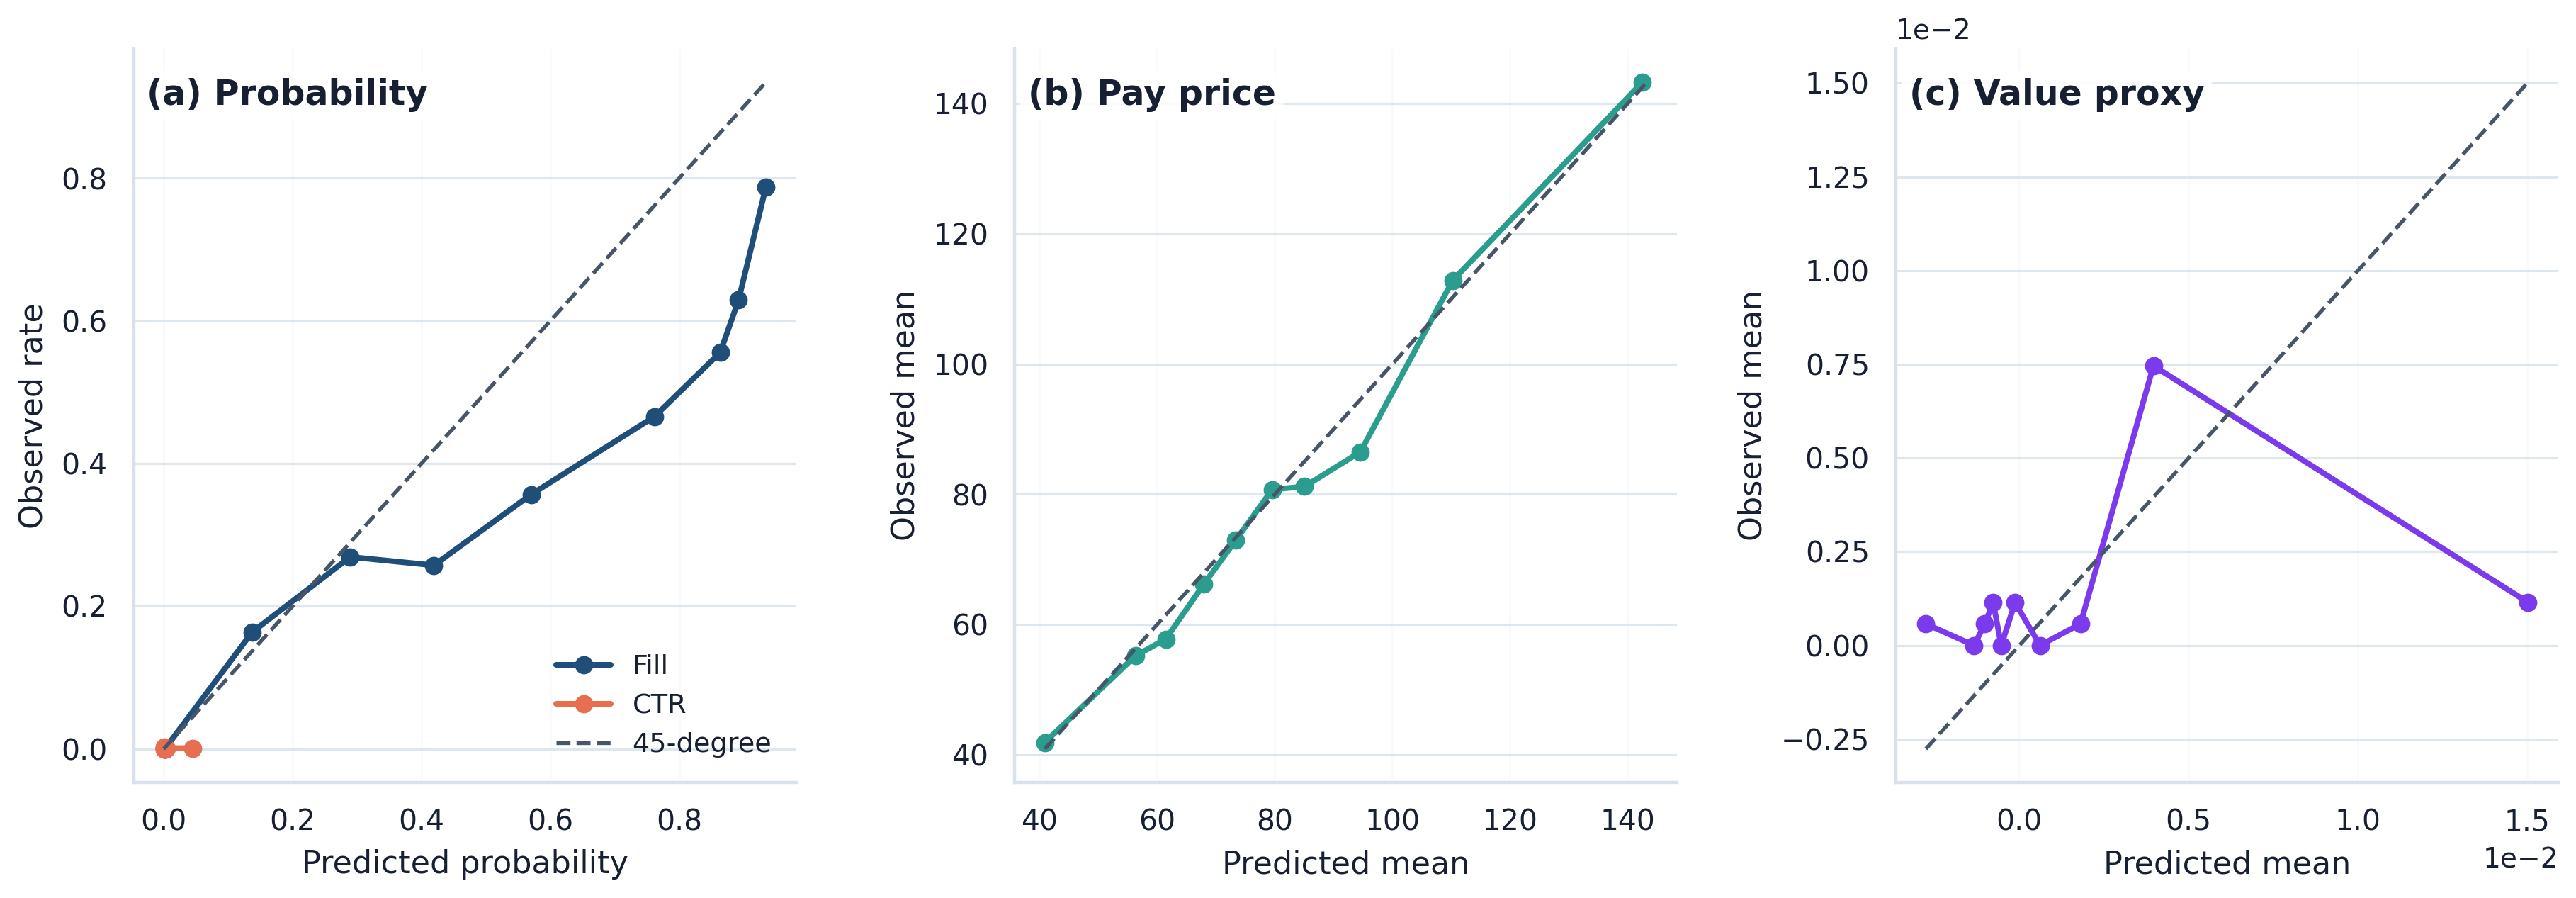

In [22]:
renderer = FigureRenderer(repository, paths.figure_dir, PaperConfig(), progress=progress)
figure_4_path = renderer.plot_calibration()
print(f"Wrote Figure 4 to {figure_4_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(figure_4_path)))


## Interpretation for the Paper

The nuisance-model diagnostic is the bridge between descriptive evidence and model-assisted causal evidence. Replay remains the mechanical foundation of the paper, but OPE and doubly robust diagnostics require learned outcome components. Figure 4 therefore answers a narrower but essential question: are those learned components being audited before they are used? The answer should be yes. The paper records model eligibility, held-out metrics, probability calibration, regression calibration, and model-specific risks before using these outputs downstream.

The right interpretation is conservative. A calibrated nuisance model does not prove that an offline policy is launch-ready. It only supports the use of model-assisted diagnostics as one part of the DSS. Weaknesses in the value-proxy model or sparse conversion target should be treated as evidence for stronger guardrails, not as a reason to overclaim model precision. The final decision still depends on replay guardrails, support diagnostics, response sensitivity, Season 3 validation, and an online validation design.
